In [0]:
patients_df = spark.read.csv(
    '/Volumes/capstone_05/default/capstone_vol/patients.csv',
    header=True,
    inferSchema=True
)

doctors_df = spark.read.csv(
    '/Volumes/capstone_05/default/capstone_vol/doctors.csv',
    header=True,
    inferSchema=True
)

appointments_df = spark.read.csv(
    '/Volumes/capstone_05/default/capstone_vol/appointments.csv',
    header=True,
    inferSchema=True
)

preferences_df = spark.read.options(
    multiline=True
).json('/Volumes/capstone_05/default/capstone_vol/patient_preferences.json')

In [0]:
patients_df.printSchema()
doctors_df.printSchema()
appointments_df.printSchema()
preferences_df.printSchema()

root
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)

root
 |-- doctor_id: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)

root
 |-- appointment_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |--  status: string (nullable = true)

root
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- preferred_hospit

In [0]:
patients_df.write.format('delta').mode('overwrite').save(
    '/Volumes/capstone_05/default/capstone_vol/bronze/patients'
)

doctors_df.write.format('delta').mode('overwrite').save(
    '/Volumes/capstone_05/default/capstone_vol/bronze/doctors'
)

appointments_df.write.format('delta').mode('overwrite').save(
    '/Volumes/capstone_05/default/capstone_vol/bronze/appointments'
)

preferences_df.write.format('delta').mode('overwrite').save(
    '/Volumes/capstone_05/default/capstone_vol/bronze/preferences'
)

In [0]:
from pyspark.sql.functions import *

def null_counter(df):
    df.select([
        count(when(col(c).isNull(), c)).alias(c) for c in df.columns
    ]).show()

null_counter(patients_df)
null_counter(doctors_df)
null_counter(appointments_df)
null_counter(preferences_df)

+----------+------------+----+-----+---+------+----------------+
|patient_id|patient_name|city|state|age|gender|insurance_status|
+----------+------------+----+-----+---+------+----------------+
|         0|           0|   0|    0|  0|     0|               0|
+----------+------------+----+-----+---+------+----------------+

+---------+-----------+----------+----+----------------+
|doctor_id|doctor_name|department|city|consultation_fee|
+---------+-----------+----------+----+----------------+
|        0|          0|         0|   0|               0|
+---------+-----------+----------+----+----------------+

+--------------+----------+---------+----------------+---------+-----------+------+
|appointment_id|patient_id|doctor_id|appointment_date|diagnosis|bill_amount|status|
+--------------+----------+---------+----------------+---------+-----------+------+
|             0|         0|        0|               0|        0|          0|     0|
+--------------+----------+---------+---------------

In [0]:
flat_preferences_df = preferences_df.select(
    '*',
    col('contact.phone').alias('phone'),
    col('contact.email').alias('email')
)

In [0]:
flat_preferences_df.show()

+--------------------+----------+------------------+----------+--------------+
|             contact|patient_id|preferred_hospital|     phone|         email|
+--------------------+----------+------------------+----------+--------------+
|{rahul@mail.com, ...|      P101|   Apollo Hospital|9876500011|rahul@mail.com|
|{priya@mail.com, ...|      P102|  Yashoda Hospital|9876500012|priya@mail.com|
|{sneha@mail.com, ...|      P104|     Care Hospital|9876500014|sneha@mail.com|
|{meera@mail.com, ...|      P108|   Apollo Hospital|9876500018|meera@mail.com|
+--------------------+----------+------------------+----------+--------------+



In [0]:

full_df = patients_df.join(
    preferences_df,
    'patient_id',
    'left'
).join(
    appointments_df,
    'patient_id',
    'left'
).join(
    doctors_df.withColumnRenamed('city', 'doctor_city'),
    'doctor_id',
    'left'
)

In [0]:
full_df.show()

+---------+----------+------------+---------+-----------+---+------+----------------+--------------------+------------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+-----------+----------------+
|doctor_id|patient_id|patient_name|     city|      state|age|gender|insurance_status|             contact|preferred_hospital|appointment_id|appointment_date|     diagnosis|bill_amount|   status|doctor_name| department|doctor_city|consultation_fee|
+---------+----------+------------+---------+-----------+---+------+----------------+--------------------+------------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+-----------+----------------+
|     D106|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|{rahul@mail.com, ...|   Apollo Hospital|         A1009|      2026-06-05|Cardiac Review|       6500|Completed|  Dr. Kiran| Cardiology|  Hyderabad|            3000|
|     D1

In [0]:
full_df = full_df.withColumn(
    'final_bill',
    col('bill_amount') + col('consultation_fee')
).withColumn(
    'appointment_month',
    month(col('appointment_date'))
).withColumn(
    'patient_age_group',
    when(col('age') >= 50, 'Senior')
    .when(col('age') >= 30, 'Adult')
    .otherwise('Young')
)

full_df.show()


+---------+----------+------------+---------+-----------+---+------+----------------+--------------------+------------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|patient_name|     city|      state|age|gender|insurance_status|             contact|preferred_hospital|appointment_id|appointment_date|     diagnosis|bill_amount|   status|doctor_name| department|doctor_city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+------------+---------+-----------+---+------+----------------+--------------------+------------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D106|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|{rahul@mail.com, ...|   Apollo

In [0]:
full_df.write.format('delta').mode('overwrite').save(
    '/Volumes/capstone_05/default/capstone_vol/silver/full_df'
)

flat_preferences_df.write.format('delta').mode('overwrite').save(
    '/Volumes/capstone_05/default/capstone_vol/silver/flat_preferences'
)

In [0]:
full_df.createOrReplaceTempView('df')
appointments_df.createOrReplaceTempView('appointments')

In [0]:
%sql

select preferred_hospital, sum(final_bill) as revenue from df
group by preferred_hospital;

preferred_hospital,revenue
Apollo Hospital,19500
Care Hospital,21500
Yashoda Hospital,5500
null,22700


In [0]:
%sql
select department, sum(final_bill) as revenue from df
group by department;

department,revenue
Orthopedics,21500
Cardiology,33000
Pediatrics,2700
Dermatology,6500
Neurology,5500


In [0]:
%sql
select city, sum(final_bill) as revenue from df
group by city;

city,revenue
Delhi,21500
Chennai,2700
Kochi,3500
Hyderabad,23000
Bangalore,5500
Pune,10000
Mumbai,3000


In [0]:
%sql
select * from appointments where status = 'Completed';

appointment_id,patient_id,doctor_id,appointment_date,diagnosis,bill_amount,status
A1001,P101,D101,2026-06-01,Heart Checkup,5000,Completed
A1002,P102,D102,2026-06-01,Migraine,3500,Completed
A1004,P104,D104,2026-06-02,Fracture,12000,Completed
A1005,P105,D105,2026-06-03,Fever,1500,Completed
A1006,P106,D106,2026-06-03,Heart Checkup,7000,Completed
A1007,P107,D101,2026-06-04,Chest Pain,5500,Completed
A1009,P101,D106,2026-06-05,Cardiac Review,6500,Completed


In [0]:
%sql
select patient_id, patient_name from df 
group by patient_id, patient_name 
order by sum(final_bill) desc limit 5;

patient_id,patient_name
P104,Sneha Patel
P101,Rahul Sharma
P106,Neha Singh
P107,Arjun Verma
P102,Priya Reddy


In [0]:
from pyspark.sql.window import Window as win

doctor_revenue_df = full_df.groupBy(
    'doctor_id',
    'doctor_name',
    'department'
).agg(
    sum('final_bill').alias('revenue')
)

win_spec = win.orderBy(col('revenue').desc())

doctor_rank_df = doctor_revenue_df.withColumn(
    'rank',
    rank().over(win_spec)
)

print('Doctors Ranked by Revenue')
doctor_rank_df.show()

department_revenue_df = full_df.groupBy(
    'department'
).agg(
    sum('final_bill').alias('revenue')
)

win_spec = win.orderBy(col('revenue').desc())

department_rank_df = department_revenue_df.withColumn(
    'rank',
    rank().over(win_spec)
)

print('Departments Ranked by Revenue')
department_rank_df.show()

patient_revenue_df = full_df.groupBy(
    'patient_id',
    'patient_name',
    'patient_age_group'
).agg(
    sum('final_bill').alias('revenue')
)

win_spec = win.orderBy(col('revenue').desc())

top_patients_df = patient_revenue_df.withColumn(
    'rank',
    rank().over(win_spec)
).filter(
    col('rank') <= 3
)

print('Top 3 Patients by Billing')
top_patients_df.show()

doctor_department_df = full_df.groupBy(
    'doctor_id',
    'doctor_name',
    'department'
).agg(
    sum('final_bill').alias('revenue')
)

win_spec = win.partitionBy(
    'department'
).orderBy(
    col('revenue').desc()
)

top_doctor_df = doctor_department_df.withColumn(
    'rank',
    rank().over(win_spec)
).filter(
    col('rank') == 1
)

print('Top Doctor in Each Department')
top_doctor_df.show()

daily_revenue_df = full_df.groupBy(
    'appointment_date'
).agg(
    sum('final_bill').alias('daily_revenue')
)

win_spec = win.orderBy(
    'appointment_date'
).rowsBetween(
    win.unboundedPreceding,
    win.currentRow
)

running_revenue_df = daily_revenue_df.withColumn(
    'running_revenue',
    sum('daily_revenue').over(win_spec)
)

print('Running Revenue by Appointment Date')
running_revenue_df.show()

Doctors Ranked by Revenue
+---------+-----------+-----------+-------+----+
|doctor_id|doctor_name| department|revenue|rank|
+---------+-----------+-----------+-------+----+
|     D104| Dr. Suresh|Orthopedics|  21500|   1|
|     D106|  Dr. Kiran| Cardiology|  19500|   2|
|     D101| Dr. Ramesh| Cardiology|  13500|   3|
|     D103|  Dr. Anita|Dermatology|   6500|   4|
|     D102|  Dr. Priya|  Neurology|   5500|   5|
|     D105|  Dr. Meera| Pediatrics|   2700|   6|
+---------+-----------+-----------+-------+----+

Departments Ranked by Revenue
+-----------+-------+----+
| department|revenue|rank|
+-----------+-------+----+
| Cardiology|  33000|   1|
|Orthopedics|  21500|   2|
|Dermatology|   6500|   3|
|  Neurology|   5500|   4|
| Pediatrics|   2700|   5|
+-----------+-------+----+

Top 3 Patients by Billing
+----------+------------+-----------------+-------+----+
|patient_id|patient_name|patient_age_group|revenue|rank|
+----------+------------+-----------------+-------+----+
|      P104|

In [0]:
full_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/Volumes/capstone_05/default/capstone_vol/delta/hospital_data")

delta_df = spark.read.format("delta").load(
    "/Volumes/capstone_05/default/capstone_vol/delta/hospital_data"
)

delta_df.show()

+---------+----------+------------+---------+-----------+---+------+----------------+--------------------+------------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|patient_name|     city|      state|age|gender|insurance_status|             contact|preferred_hospital|appointment_id|appointment_date|     diagnosis|bill_amount|   status|doctor_name| department|doctor_city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+------------+---------+-----------+---+------+----------------+--------------------+------------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D106|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|{rahul@mail.com, ...|   Apollo

In [0]:
full_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("hospital_delta")

full_df.createOrReplaceTempView("hospital_temp")

In [0]:
%sql
CREATE OR REPLACE TABLE hospital_sql_delta
USING DELTA
AS
SELECT *
FROM hospital_temp;

num_affected_rows,num_inserted_rows


In [0]:
%sql
describe history hospital_sql_delta

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T05:26:28.000Z,146722045516591,azuser7218_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.format.version"":""2.12.0"",""delta.parquet.format.version.afe.internal"":""2.12.0"",""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(511196128278472),62c93b48-b7e5-4177-a1fa-07413ce4d485,0622-041255-3ofal87z-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 7415)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
v0_hospital_sql_delta = spark.read.format('delta').option('versionAsOf', 0).table('hospital_delta')

v0_hospital_sql_delta.show()

+---------+----------+------------+---------+-----------+---+------+----------------+--------------------+------------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|patient_name|     city|      state|age|gender|insurance_status|             contact|preferred_hospital|appointment_id|appointment_date|     diagnosis|bill_amount|   status|doctor_name| department|doctor_city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+------------+---------+-----------+---+------+----------------+--------------------+------------------+--------------+----------------+--------------+-----------+---------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D106|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|{rahul@mail.com, ...|   Apollo

In [0]:
patients_data = [
    ("P101", "Rahul Sharma", "Hyderabad", "Active"),
    ("P102", "Priya Reddy", "Bangalore", "Active"),
    ("P103", "Amit Kumar", "Mumbai", "Inactive"),
    ("P104", "Sneha Patel", "Delhi", "Active")
]

target_df = spark.createDataFrame(
    patients_data,
    ["patient_id", "patient_name", "city", "insurance_status"]
)

target_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("patients_delta")

spark.sql("SELECT * FROM patients_delta").show()

+----------+------------+---------+----------------+
|patient_id|patient_name|     city|insurance_status|
+----------+------------+---------+----------------+
|      P101|Rahul Sharma|Hyderabad|          Active|
|      P102| Priya Reddy|Bangalore|          Active|
|      P103|  Amit Kumar|   Mumbai|        Inactive|
|      P104| Sneha Patel|    Delhi|          Active|
+----------+------------+---------+----------------+



In [0]:
updates_data = [
    ("P101", "Chennai", "Inactive"),    # Existing patient updated
    ("P104", "Pune", "Inactive"),       # Existing patient updated
    ("P105", "Coimbatore", "Active")    # New patient
]

source_df = spark.createDataFrame(
    updates_data,
    ["patient_id", "city", "insurance_status"]
)

source_df.show()

+----------+----------+----------------+
|patient_id|      city|insurance_status|
+----------+----------+----------------+
|      P101|   Chennai|        Inactive|
|      P104|      Pune|        Inactive|
|      P105|Coimbatore|          Active|
+----------+----------+----------------+



In [0]:
from delta.tables import DeltaTable

delta_table = DeltaTable.forName(spark, "patients_delta")

delta_table.alias("target").merge(
    source_df.alias("source"),
    "target.patient_id = source.patient_id"
).whenMatchedUpdate(
    set={
        "city": "source.city",
        "insurance_status": "source.insurance_status"
    }
).whenNotMatchedInsert(
    values={
        "patient_id": "source.patient_id",
        "patient_name": "NULL",
        "city": "source.city",
        "insurance_status": "source.insurance_status"
    }
).execute()

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
%sql describe history patients_delta

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
1,2026-06-22T05:39:36.000Z,146722045516591,azuser7218_mml.local@karthikirisoutlook.onmicrosoft.com,MERGE,"Map(predicate -> [""(patient_id#19687 = patient_id#19703)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [{""actionType"":""insert""}])",null,List(511196128278472),eac8b55a-1802-4139-882d-0f5a5f889cf3,0622-041255-3ofal87z-v2n,0,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 3, numTargetBytesAdded -> 4607, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 2, executionTimeMs -> 4244, materializeSourceTimeMs -> 226, numTargetRowsInserted -> 1, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 2007, numTargetRowsUpdated -> 2, numOutputRows -> 3, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 3, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 1930)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-22T05:35:16.000Z,146722045516591,azuser7218_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.format.version"":""2.12.0"",""delta.parquet.format.version.afe.internal"":""2.12.0"",""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(511196128278472),33354562-bed6-45d8-ab6c-11b8bff4523d,0622-041255-3ofal87z-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 4, numOutputBytes -> 1704)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
%sql 

optimize patients_delta;

optimize patients_delta
zorder by city;

vacuum patients_delta;

path
""


In [0]:
from matplotlib import pyplot as plt

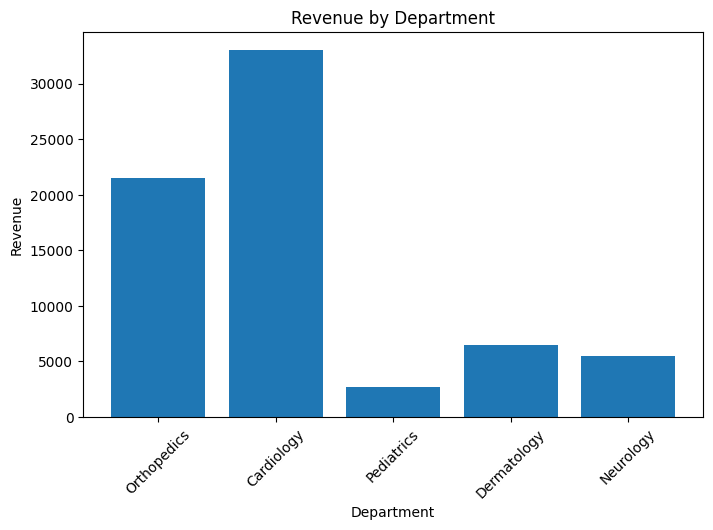

In [0]:
dept_rev = full_df.groupBy('department').agg(sum('final_bill').alias('revenue'))

dept_rev = dept_rev.toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_rev['department'], dept_rev['revenue'])
plt.xlabel('Department')
plt.ylabel('Revenue')
plt.title('Revenue by Department')
plt.xticks(rotation=45)
plt.show()

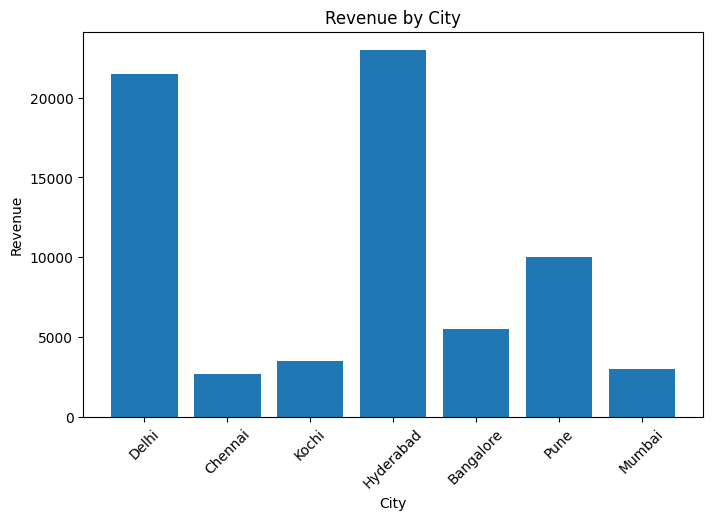

In [0]:
city_rev = full_df.groupBy('city').agg(sum('final_bill').alias('revenue'))

city_rev = city_rev.toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_rev['city'], city_rev['revenue'])
plt.xlabel('City')
plt.ylabel('Revenue')
plt.title('Revenue by City')
plt.xticks(rotation=45)
plt.show()

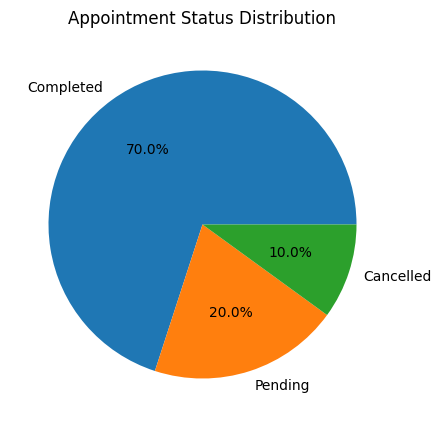

In [0]:
status_dis = full_df.select('status').toPandas()

plt.figure(figsize=(8,5))
plt.pie(
    status_dis['status'].value_counts(), 
    labels=status_dis['status'].value_counts().index, 
    autopct='%1.1f%%'
)
plt.title('Appointment Status Distribution')
plt.show()

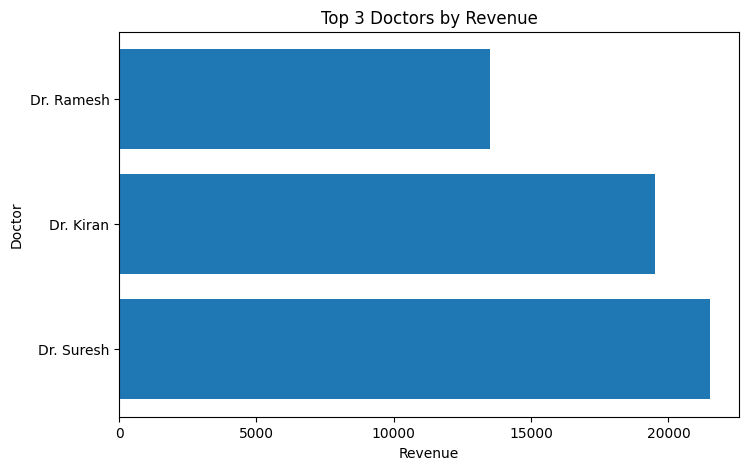

In [0]:
doc_rev = full_df.groupBy(
    'doctor_id',
    'doctor_name'
).agg(sum('final_bill').alias('revenue')).orderBy(desc('revenue')
).limit(3)

doc_rev_pd = doc_rev.toPandas()

plt.figure(figsize=(8,5))
plt.barh(doc_rev_pd['doctor_name'], doc_rev_pd['revenue'])
plt.xlabel('Revenue')
plt.ylabel('Doctor')
plt.title('Top 3 Doctors by Revenue')
plt.show()

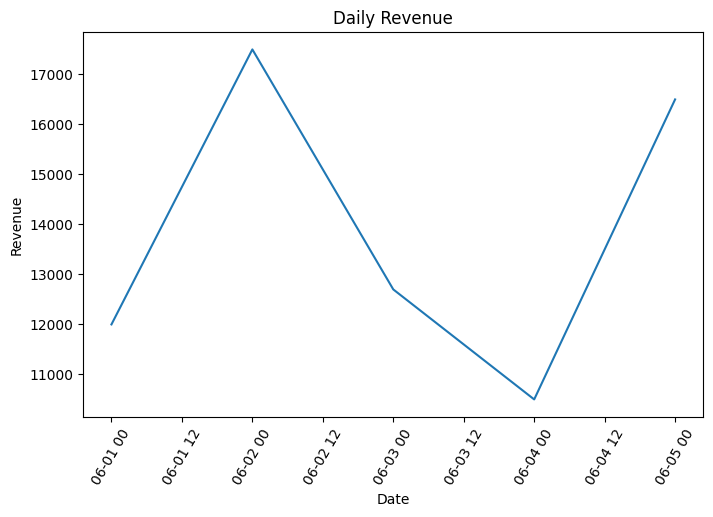

In [0]:
rev_dat = full_df.groupBy('appointment_date').agg(sum('final_bill').alias('revenue')).orderBy('appointment_date')

rev_dat_pd = rev_dat.toPandas()

plt.figure(figsize=(8,5))
plt.plot(rev_dat_pd['appointment_date'], rev_dat_pd['revenue'])
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=60)
plt.title('Daily Revenue')      
plt.show()

In [0]:
full_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("hospital_managed")

In [0]:
%sql
SELECT * FROM hospital_managed;

doctor_id,patient_id,patient_name,city,state,age,gender,insurance_status,contact,preferred_hospital,appointment_id,appointment_date,diagnosis,bill_amount,status,doctor_name,department,doctor_city,consultation_fee,final_bill,appointment_month,patient_age_group
D106,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,"List(rahul@mail.com, 9876500011)",Apollo Hospital,A1009,2026-06-05,Cardiac Review,6500,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,9500,6,Adult
D102,P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,"List(priya@mail.com, 9876500012)",Yashoda Hospital,A1002,2026-06-01,Migraine,3500,Completed,Dr. Priya,Neurology,Bangalore,2000,5500,6,Young
D103,P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,null,null,A1003,2026-06-02,Skin Allergy,2000,Pending,Dr. Anita,Dermatology,Chennai,1000,3000,6,Adult
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,"List(sneha@mail.com, 9876500014)",Care Hospital,A1010,2026-06-05,Back Pain,4500,Cancelled,Dr. Suresh,Orthopedics,Mumbai,2500,7000,6,Adult
D105,P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,A1005,2026-06-03,Fever,1500,Completed,Dr. Meera,Pediatrics,Delhi,1200,2700,6,Senior
D106,P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,A1006,2026-06-03,Heart Checkup,7000,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,10000,6,Adult
D101,P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,A1007,2026-06-04,Chest Pain,5500,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,7000,6,Young
D103,P108,Meera Nair,Kochi,Kerala,48,Female,Active,"List(meera@mail.com, 9876500018)",Apollo Hospital,A1008,2026-06-04,Skin Infection,2500,Pending,Dr. Anita,Dermatology,Chennai,1000,3500,6,Adult
D101,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,"List(rahul@mail.com, 9876500011)",Apollo Hospital,A1001,2026-06-01,Heart Checkup,5000,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,6500,6,Adult
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,"List(sneha@mail.com, 9876500014)",Care Hospital,A1004,2026-06-02,Fracture,12000,Completed,Dr. Suresh,Orthopedics,Mumbai,2500,14500,6,Adult


In [0]:
full_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/Volumes/capstone_05/default/capstone_vol/external/hospital_ext")

In [0]:
%sql
CREATE TABLE hospital_external
USING DELTA
LOCATION '/Volumes/capstone_05/default/capstone_vol/external/hospital_ext';

select * from hospital_external;

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-4904072386936995>, line 1
----> 1 get_ipython().run_cell_magic('sql', '', "CREATE TABLE hospital_external\nUSING DELTA\nLOCATION '/Volumes/capstone_05/default/capstone_vol/external/hospital_ext';\n\nselect * from hospital_external;\n")

File /databricks/python/lib/python3.12/site-packages/IPython/core/interactiveshell.py:2541, in InteractiveShell.run_cell_magic(self, magic_name, line, cell)
   2539 with self.builtin_trap:
   2540     args = (magic_arg_s, cell)
-> 2541     result = fn(*args, **kwargs)
   2543 # The code below prevents the output from being displayed
   2544 # when using magics with decorator @output_can_be_silenced
   2545 # when the last Python token in the expression is a ';'.
   2546 if getattr(fn, magic.MAGIC_OUTPUT_CAN_BE_SILENCED, False):

File /databricks/python_shell/lib/dbruntime/sql_magic/sql_magi

In [0]:
full_df.createOrReplaceTempView("hospital_temp")

In [0]:
%sql
SELECT * FROM hospital_temp;

doctor_id,patient_id,patient_name,city,state,age,gender,insurance_status,contact,preferred_hospital,appointment_id,appointment_date,diagnosis,bill_amount,status,doctor_name,department,doctor_city,consultation_fee,final_bill,appointment_month,patient_age_group
D106,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,"List(rahul@mail.com, 9876500011)",Apollo Hospital,A1009,2026-06-05,Cardiac Review,6500,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,9500,6,Adult
D102,P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,"List(priya@mail.com, 9876500012)",Yashoda Hospital,A1002,2026-06-01,Migraine,3500,Completed,Dr. Priya,Neurology,Bangalore,2000,5500,6,Young
D103,P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,null,null,A1003,2026-06-02,Skin Allergy,2000,Pending,Dr. Anita,Dermatology,Chennai,1000,3000,6,Adult
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,"List(sneha@mail.com, 9876500014)",Care Hospital,A1010,2026-06-05,Back Pain,4500,Cancelled,Dr. Suresh,Orthopedics,Mumbai,2500,7000,6,Adult
D105,P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,A1005,2026-06-03,Fever,1500,Completed,Dr. Meera,Pediatrics,Delhi,1200,2700,6,Senior
D106,P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,A1006,2026-06-03,Heart Checkup,7000,Completed,Dr. Kiran,Cardiology,Hyderabad,3000,10000,6,Adult
D101,P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,A1007,2026-06-04,Chest Pain,5500,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,7000,6,Young
D103,P108,Meera Nair,Kochi,Kerala,48,Female,Active,"List(meera@mail.com, 9876500018)",Apollo Hospital,A1008,2026-06-04,Skin Infection,2500,Pending,Dr. Anita,Dermatology,Chennai,1000,3500,6,Adult
D101,P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,"List(rahul@mail.com, 9876500011)",Apollo Hospital,A1001,2026-06-01,Heart Checkup,5000,Completed,Dr. Ramesh,Cardiology,Hyderabad,1500,6500,6,Adult
D104,P104,Sneha Patel,Delhi,Delhi,31,Female,Active,"List(sneha@mail.com, 9876500014)",Care Hospital,A1004,2026-06-02,Fracture,12000,Completed,Dr. Suresh,Orthopedics,Mumbai,2500,14500,6,Adult


In [0]:
"""full_df.createOrReplaceGlobalTempView("hospital_global_temp")
%sql
SELECT * FROM global_temp.hospital_global_temp;"""

# need access permissions and more 

'full_df.createOrReplaceGlobalTempView("hospital_global_temp")\n%sql\nSELECT * FROM global_temp.hospital_global_temp;'

In [0]:
"""
    *managed tables are tables that are presistent and created by databricks itself.
    *un-managed tables are tales that are created someware and loaded via volume
    *temp_view are tables that are not presistent and created for a simple eda purpose 
"""
"""
    *managed are available between notebooks
    *un-managed also available between notebooks
    *temp_view are not available between notebooks
"""

'\n    *managed are available between notebooks\n    *un-managed also available between notebooks\n    \n'

In [0]:
"""
Managed tables:
* Available across notebooks and sessions (subject to permissions).
* Exist until explicitly dropped.

External tables:
* Available across notebooks and sessions (subject to permissions).
* Exist until explicitly dropped.

Temporary views:
* Available only within the current Spark session/notebook.
* Removed automatically when the session ends.

Global temporary views:
* Available across notebooks attached to the same cluster/application.
* Removed when the Spark application or cluster terminates.
"""

In [0]:
full_df.printSchema()

root
 |-- doctor_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullable = true)
 |-- preferred_hospital: string (nullable = true)
 |-- appointment_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- doctor_city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)
 |-- final_bill: integer (nullable = true)
 |-- appointment_month: integer (nullable = true)
 |-- patient_ag

In [0]:
patients_df.printSchema()
doctors_df.printSchema()
appointments_df.printSchema()
preferences_df.printSchema()

root
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)

root
 |-- doctor_id: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)

root
 |-- appointment_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)

root
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- preferred_hospita